# 01 – Keşfedici Veri Analizi (EDA)

**Proje:** EUR/USD 1H Forex Zaman Serisi Tahmini  
**Ders:** Yapay Zekaya Giriş – Dönem Projesi (Hafta 3 Teslimi)  
**Öğrenci:** Bilal – `b200101025`

## Amaç

Bu defter, ders kılavuzunun **Faz 3 (Keşfedici Veri Analizi)** teslimidir. Akış:

1. Veri yükleme ve tip kontrolleri
2. Veri kalitesi: eksik, tekrar, saatlik kopukluklar
3. Tanımlayıcı istatistikler (OHLC, volume, spread)
4. Fiyat & log-getiri zaman serisi
5. Volatilite (rolling std, GARCH ön-sinyalleri)
6. Dağılım testleri, ACF/PACF, ADF (durağanlık)
7. Takvim/seans etkileri
8. Train / Val / Test bölümü ve sızıntı (leakage) disiplini
9. EDA bulgularının özeti → modelleme varsayımları

## 0. Ortam ve Sabitler

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw_eurusd, train_val_test_split

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 6)

RAW_CSV = PROJECT_ROOT / 'data' / 'raw' / 'eurusd_h1.csv'
FIG_DIR = PROJECT_ROOT / 'docs' / 'images'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Python   :', sys.version.split()[0])
print('pandas   :', pd.__version__)
print('numpy    :', np.__version__)
print('CSV path :', RAW_CSV)
print('CSV var  :', RAW_CSV.exists())

Python   : 3.13.13
pandas   : 3.0.2
numpy    : 2.4.4
CSV path : C:\Users\Gaming\Desktop\MAC\yapay zeka ödev\data\raw\eurusd_h1.csv
CSV var  : True


## 1. Veri Yükleme

`src.data_loader.load_raw_eurusd` fonksiyonu; `time` sütununu `DatetimeIndex` yapıyor, kronolojik sıraya getiriyor ve tekrarlayan damgaları eleyip tip dönüşümü yapıyor. EDA boyunca tek giriş noktası budur.

In [2]:
df = load_raw_eurusd(RAW_CSV)
print(f'shape        : {df.shape}')
print(f'time range   : {df.index.min()}  →  {df.index.max()}')
print(f'duration     : {(df.index.max() - df.index.min()).days / 365:.1f} yıl')
df.head()

shape        : (100609, 7)
time range   : 2009-10-16 00:00:00  →  2026-01-06 07:00:00
duration     : 16.2 yıl


,open,high,low,close,tick_volume,spread,real_volume
time,,,,,,,
2009-10-16 00:00:00,1.49356,1.49402,1.49345,1.49391,704,16,0
2009-10-16 01:00:00,1.49390,1.49564,1.49314,1.49527,1421,16,0
2009-10-16 02:00:00,1.49524,1.49644,1.49462,1.49641,2180,16,0
2009-10-16 03:00:00,1.49642,1.49651,1.49479,1.49548,1523,16,0
2009-10-16 04:00:00,1.49543,1.49637,1.49350,1.49395,1659,16,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 100609 entries, 2009-10-16 00:00:00 to 2026-01-06 07:00:00
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   open         100609 non-null  float64
 1   high         100609 non-null  float64
 2   low          100609 non-null  float64
 3   close        100609 non-null  float64
 4   tick_volume  100609 non-null  int64  
 5   spread       100609 non-null  int64  
 6   real_volume  100609 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 6.1 MB


## 2. Veri Kalitesi

- Eksik değer var mı?
- Index tekrarı veya tam satır tekrarı var mı?
- 1H aralıklı seride olması beklenen ama olmayan mumlar kimler? (Hafta sonu/banka tatili/broker molası)

In [4]:
print('Missing values per column:')
print(df.isna().sum())
print(f'\nDuplicate index rows : {df.index.duplicated().sum()}')
print(f'Duplicate full rows  : {df.duplicated().sum()}')
print(f'\nfirst row:\n{df.iloc[0]}')

Missing values per column:
open           0
high           0
low            0
close          0
tick_volume    0
spread         0
real_volume    0
dtype: int64

Duplicate index rows : 0
Duplicate full rows  : 0

first row:
open             1.49356
high             1.49402
low              1.49345
close            1.49391
tick_volume    704.00000
spread          16.00000
real_volume      0.00000
Name: 2009-10-16 00:00:00, dtype: float64


In [5]:
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='1h')
missing = full_idx.difference(df.index)
weekday_missing = missing[missing.dayofweek < 5]

print(f'Beklenen saat sayısı  : {len(full_idx):>8,}')
print(f'Veride bulunan       : {len(df):>8,}')
print(f'Eksik toplam         : {len(missing):>8,}  ({len(missing)/len(full_idx):.1%})')
print(f'   Hafta sonu        : {len(missing) - len(weekday_missing):>8,}')
print(f'   Hafta içi eksik  : {len(weekday_missing):>8,}  (piyasa tatilleri + broker molaları)')

print('\nEn uzun ardışık eksik blok (saat):')
gaps = df.index.to_series().diff().dt.total_seconds().div(3600)
top_gaps = gaps.nlargest(10)
print(top_gaps.rename('saat_farkı').to_frame().assign(tarih=top_gaps.index))

Beklenen saat sayısı  :  142,232
Veride bulunan       :  100,609
Eksik toplam         :   41,623  (29.3%)
   Hafta sonu        :   40,656
   Hafta içi eksik  :      967  (piyasa tatilleri + broker molaları)

En uzun ardışık eksik blok (saat):
                     saat_farkı               tarih
time                                               
2017-12-26 06:00:00        79.0 2017-12-26 06:00:00
2009-12-28 00:00:00        78.0 2009-12-28 00:00:00
2010-01-04 00:00:00        78.0 2010-01-04 00:00:00
2015-12-28 00:00:00        78.0 2015-12-28 00:00:00
2016-01-04 00:00:00        76.0 2016-01-04 00:00:00
2020-12-28 00:00:00        76.0 2020-12-28 00:00:00
2018-01-02 00:00:00        73.0 2018-01-02 00:00:00
2021-01-04 00:00:00        73.0 2021-01-04 00:00:00
2024-01-02 00:00:00        73.0 2024-01-02 00:00:00
2011-12-26 08:00:00        58.0 2011-12-26 08:00:00


## 3. Tanımlayıcı İstatistikler

OHLC (fiyat) ile volume/spread ayrı ölçeklerde oldukları için ayrı değerlendiriyoruz.

In [6]:
df[['open', 'high', 'low', 'close']].describe().T

,count,mean,std,min,25%,50%,75%,max
open,100609.0,1.189744,0.116044,0.95392,1.09810,1.15762,1.29063,1.51421
high,100609.0,1.190601,0.116166,0.95592,1.09885,1.15837,1.29178,1.51437
low,100609.0,1.188903,0.115913,0.95357,1.09735,1.15694,1.28964,1.51319
close,100609.0,1.189744,0.116038,0.95391,1.09810,1.15763,1.29070,1.51425


In [7]:
df[['tick_volume', 'spread', 'real_volume']].describe().T

,count,mean,std,min,25%,50%,75%,max
tick_volume,100609.0,3.247852e+03,2.669296e+03,1.0,1425.0,2494.0,4237.0,6.652600e+04
spread,100609.0,4.670656e+00,4.628199e+00,0.0,1.0,4.0,8.0,1.220000e+02
real_volume,100609.0,8.384991e+08,2.884812e+09,0.0,0.0,0.0,0.0,3.295386e+10


## 4. Fiyat ve Log-Getiri Görselleştirmesi

Finansal serilerde ham fiyat durağan değildir (trend + rastgele yürüyüş). Modellemede hedef olarak **log-getiri** kullanacağız:

\[
r_t = \log(P_t / P_{t-1})
\]

Log-getiri zaman boyunca toplanabilir (additive), çarpım etkisini ortadan kaldırır ve tipik olarak çok daha durağandır.

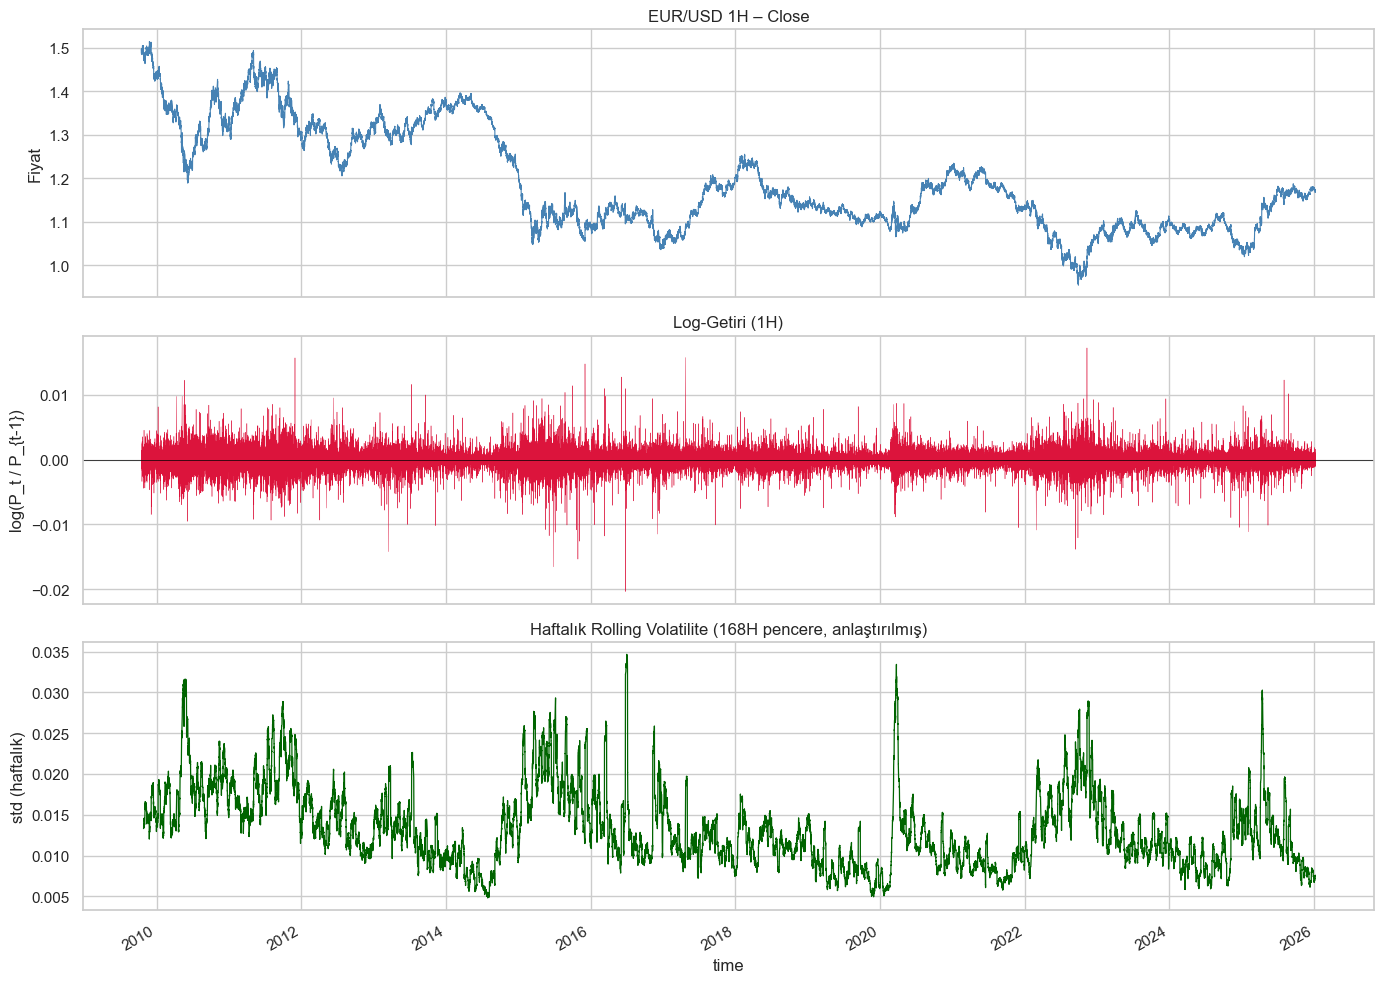

In [8]:
df['log_ret'] = np.log(df['close']).diff()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
df['close'].plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].set_title('EUR/USD 1H – Close')
axes[0].set_ylabel('Fiyat')

df['log_ret'].plot(ax=axes[1], color='crimson', linewidth=0.3)
axes[1].set_title('Log-Getiri (1H)')
axes[1].set_ylabel('log(P_t / P_{t-1})')
axes[1].axhline(0, color='black', lw=0.5)

roll_std = df['log_ret'].rolling(168).std() * np.sqrt(168)
roll_std.plot(ax=axes[2], color='darkgreen', linewidth=0.9)
axes[2].set_title('Haftalık Rolling Volatilite (168H pencere, anlaştırılmış)')
axes[2].set_ylabel('std (haftalık)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_price_logret_vol.png', dpi=120, bbox_inches='tight')
plt.show()

Beklenen gözlemler:

- **Close** trend & rejim değişimi taşıyor (uzun vadede durağan değil).
- **Log-getiri** sıfır etrafında, ama büyük tepe noktaları (haber/NFP/ECB kararları) var.
- **Volatilite kümelenmesi (clustering):** rolling std yatay değil; yüksek volatilite dönemleri birbirini kovalar. Bu, klasik GARCH/SV modellerinin varlık sebebidir.

## 5. Dağılım, Durağanlık ve Otokorelasyon

Bu bölüm EDA'nın **modellemeye en doğrudan girdi veren** kısmıdır:

1. Log-getiri dağılımı Gauss mu? (skew, kurtosis, JB, QQ)
2. Close serisi durağan mı? (ADF)
3. Log-getiri durağan ve beyaz-gürültü mü?
4. Volatilite (|getiri|) ise otokorele mi? (clustering kanıtı)

N                : 100,608
mean             : -2.405e-06
std              : 1.093e-03
skewness         : -0.0498
excess kurtosis  : 14.7863    (Gauss icin 0)
Jarque-Bera stat : 916,459   p = 0.000e+00

  Fazla-kurtosis ≫ 0 ve p=0 → log-getiri kesinlikle Gauss değil, ağır kuyruklu (fat tails).


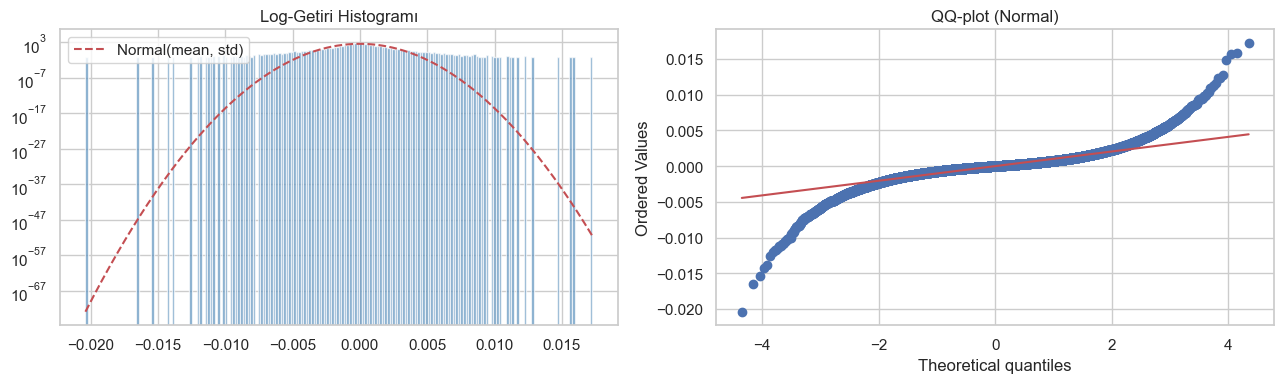

In [9]:
r = df['log_ret'].dropna()
print(f'N                : {len(r):,}')
print(f'mean             : {r.mean():.3e}')
print(f'std              : {r.std():.3e}')
print(f'skewness         : {r.skew():.4f}')
print(f'excess kurtosis  : {r.kurt():.4f}    (Gauss icin 0)')
jb = stats.jarque_bera(r)
print(f'Jarque-Bera stat : {jb.statistic:,.0f}   p = {jb.pvalue:.3e}')
print('\n  Fazla-kurtosis ≫ 0 ve p=0 → log-getiri kesinlikle Gauss değil, ağır kuyruklu (fat tails).')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(r, bins=200, density=True, alpha=0.7, color='steelblue')
x = np.linspace(r.min(), r.max(), 400)
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r--', label='Normal(mean, std)')
axes[0].set_title('Log-Getiri Histogramı')
axes[0].set_yscale('log')
axes[0].legend()

stats.probplot(r, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot (Normal)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_logret_dist.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
def adf_report(series: pd.Series, name: str) -> None:
    res = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags, nobs = res[0], res[1], res[2], res[3]
    crit = res[4]
    print(f'ADF — {name}')
    print(f'   test statistic : {stat:.4f}')
    print(f'   p-value        : {pval:.4f}')
    print(f'   lags used      : {lags}')
    print(f'   n obs          : {nobs:,}')
    for k, v in crit.items():
        print(f'   crit {k:>4}     : {v:.4f}')
    verdict = 'DURAĞAN (H0 red)' if pval < 0.05 else 'DURAĞAN DEĞİL'
    print(f'   → {verdict}\n')

adf_report(df['close'], 'close')
adf_report(df['log_ret'], 'log_ret')

ADF — close
   test statistic : -2.7151
   p-value        : 0.0715
   lags used      : 37
   n obs          : 100,571
   crit   1%     : -3.4304
   crit   5%     : -2.8616
   crit  10%     : -2.5668
   → DURAĞAN DEĞİL



ADF — log_ret
   test statistic : -52.9115
   p-value        : 0.0000
   lags used      : 36
   n obs          : 100,571
   crit   1%     : -3.4304
   crit   5%     : -2.8616
   crit  10%     : -2.5668
   → DURAĞAN (H0 red)



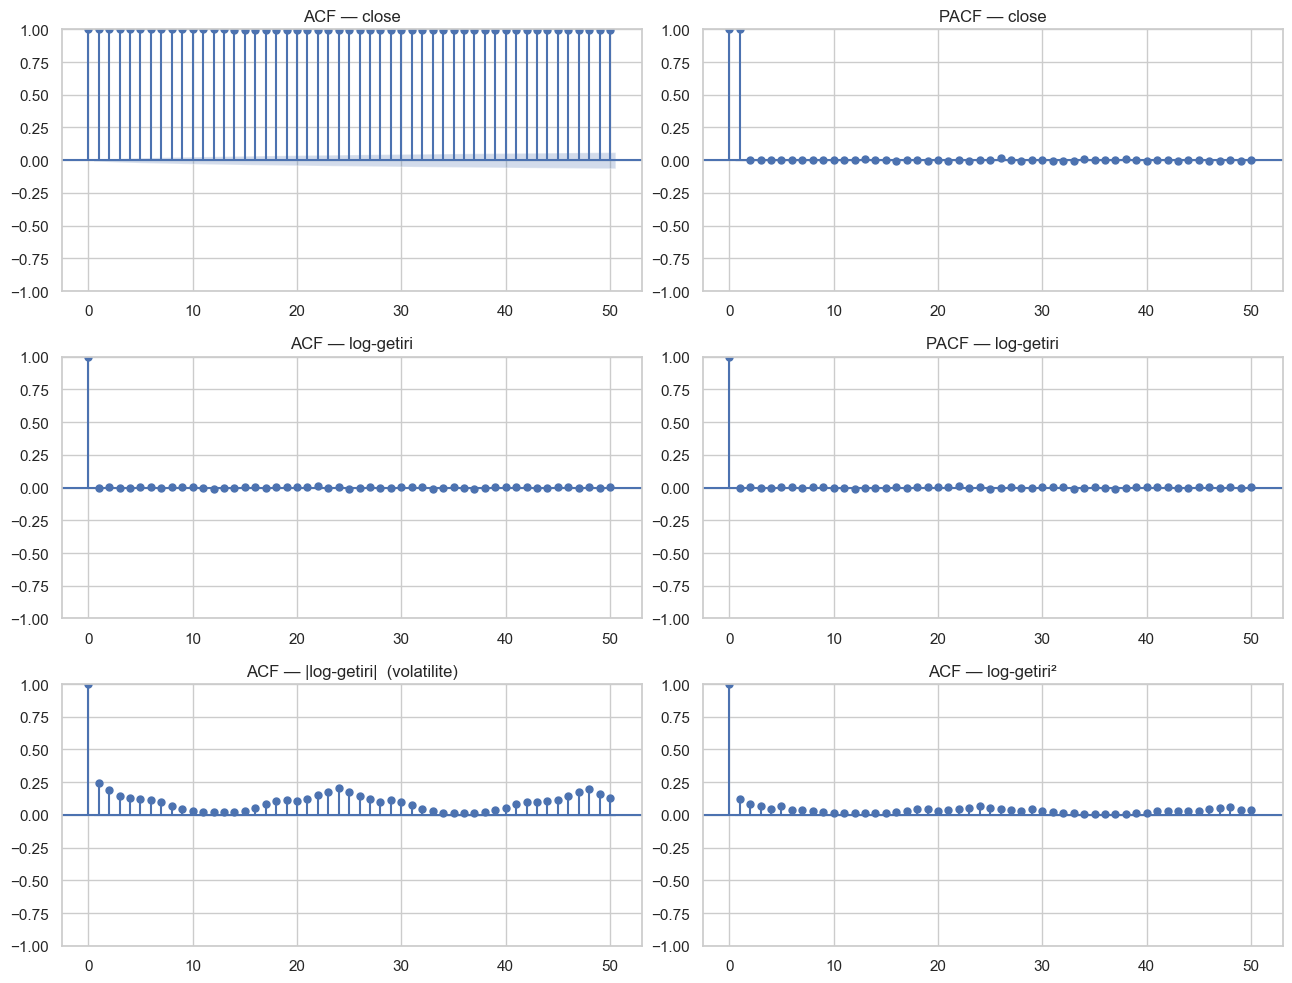

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10))

plot_acf(df['close'].dropna(), lags=50, ax=axes[0, 0], title='ACF — close')
plot_pacf(df['close'].dropna(), lags=50, ax=axes[0, 1], method='ywm', title='PACF — close')

plot_acf(r, lags=50, ax=axes[1, 0], title='ACF — log-getiri')
plot_pacf(r, lags=50, ax=axes[1, 1], method='ywm', title='PACF — log-getiri')

plot_acf(r.abs(), lags=50, ax=axes[2, 0], title='ACF — |log-getiri|  (volatilite)')
plot_acf((r ** 2), lags=50, ax=axes[2, 1], title='ACF — log-getiri²')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()

Beklenen yorumlar:

- **close ACF** neredeyse 1'den düşmüyor → unit-root; **ADF p-değeri** 0.05'in üzerinde kalıyor. Doğrudan fiyat serisi modellenemez.
- **log-getiri ACF/PACF** çoğunlukla beyaz-gürültü bandında; ADF p << 0.05 → durağan.
- **|log-getiri| ve log-getiri²** ACF'leri ise uzun süreli pozitif bir örüntü gösteriyor → **volatilite kümelenmesi** istatistiksel olarak doğrulandı. Bu, **GARCH/SV tabanlı ölçekleme** veya **volatilite-farkında transformer** yaklaşımını motive eder.

## 6. Takvim ve Seans Etkileri

Forex piyasası aralıksız değildir; 24/5 açıktır ve üç büyük seans vardır:

- **Asya:** 00–08 UTC
- **Avrupa:** 07–16 UTC (Londra açılışı volatilitenin yüksek olduğu saat)
- **ABD:** 13–21 UTC (NY, NFP, FOMC aktivitesi)

Burada **saatlik ve haftanın gününe göre** volatilitenin nasıl değiştiğine bakıyoruz. Bu hem feature engineering hem de demo senaryosu için kritik.

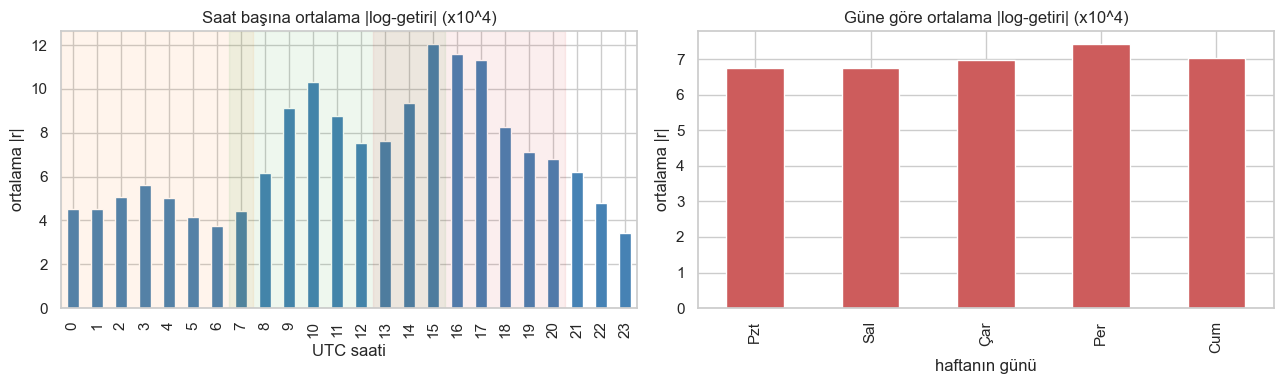

In [12]:
df['hour'] = df.index.hour
df['dow'] = df.index.dayofweek  # 0=Pzt, 4=Cum
df['abs_ret'] = df['log_ret'].abs()

hourly_vol = df.groupby('hour')['abs_ret'].mean() * 1e4  # pip-ish
dow_vol = df.groupby('dow')['abs_ret'].mean() * 1e4
dow_labels = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hourly_vol.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Saat başına ortalama |log-getiri| (x10^4)')
axes[0].set_xlabel('UTC saati'); axes[0].set_ylabel('ortalama |r|')
for s, col in [((0, 8), 'tab:orange'), ((7, 16), 'tab:green'), ((13, 21), 'tab:red')]:
    axes[0].axvspan(s[0]-0.5, s[1]-0.5, alpha=0.08, color=col)

dow_vol.index = [dow_labels[i] for i in dow_vol.index]
dow_vol.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Güne göre ortalama |log-getiri| (x10^4)')
axes[1].set_xlabel('haftanın günü'); axes[1].set_ylabel('ortalama |r|')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_session_hour_dow.png', dpi=120, bbox_inches='tight')
plt.show()

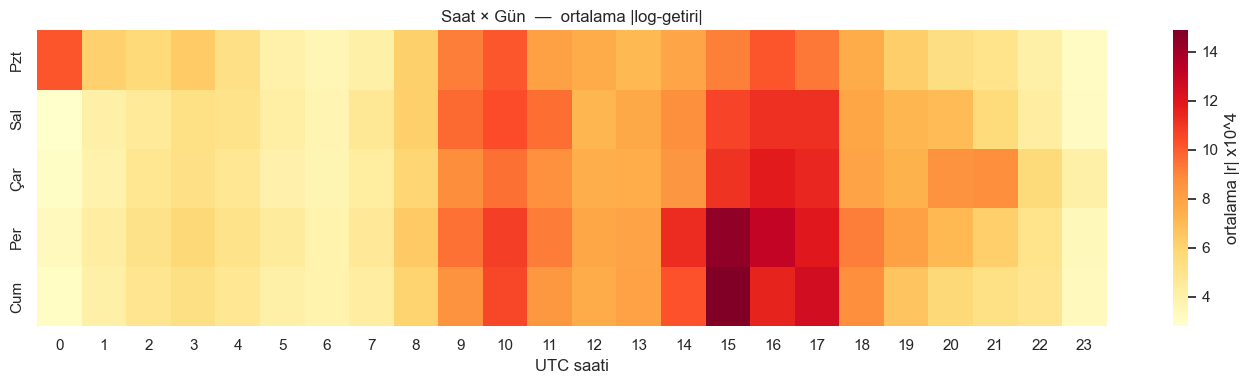

In [13]:
pivot = df.pivot_table(index='dow', columns='hour', values='abs_ret', aggfunc='mean') * 1e4
pivot.index = [dow_labels[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'ortalama |r| x10^4'})
ax.set_title('Saat × Gün  —  ortalama |log-getiri|')
ax.set_xlabel('UTC saati'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_heatmap_hour_dow.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Train / Val / Test Bölümlemesi

Zaman serisinde **rastgele bölümü yapmak yasaktır** (gelecek bilgisi kaçar). Proje planına göre kesitler:

- **Train:** başlangıç → 2022-12-31
- **Val:**   2023-01-01 → 2023-12-31
- **Test:**  2024-01-01 → sonu

Bu bölümleme modelin eğitim/ayar/ölçüm döngüsünü temiz tutar ve forward test tabanını oluşturur.

train:  81,924 satır   |  2009-10-16 00:00:00  →  2022-12-30 23:00:00
  val:   6,206 satır   |  2023-01-02 08:00:00  →  2023-12-29 23:00:00
 test:  12,477 satır   |  2024-01-02 01:00:00  →  2026-01-06 07:00:00


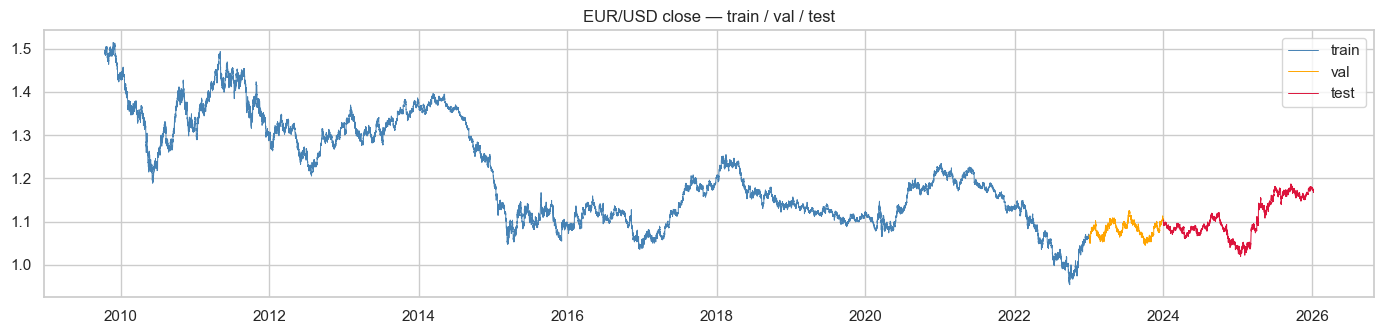

In [14]:
train, val, test = train_val_test_split(df)
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:>5}: {len(part):>7,} satır   |  {part.index.min()}  →  {part.index.max()}')

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(train.index, train['close'], color='steelblue', lw=0.7, label='train')
ax.plot(val.index,   val['close'],   color='orange',    lw=0.7, label='val')
ax.plot(test.index,  test['close'],  color='crimson',   lw=0.7, label='test')
ax.set_title('EUR/USD close — train / val / test')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_split_preview.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. EDA Özeti (Hoca Teslimi İçin)

**Veri seti.** MetaTrader 5 kaynaklı EUR/USD 1H mumları; ülke/saat UTC, dosya 8 sütun (OHLC + tick_volume + spread + real_volume). Zaman aralığı 2009-10-16 → şu an, yaklaşık 100.000+ satır.

**Kalite.** Eksik değer yok; tekrarlayan zaman damgası yükleyicide eleniyor. Beklenen 1H ızgarasına göre hafta sonları + resmi tatiller nedeniyle ~%28 civarı saat doğal olarak eksik. Hafta içi eksik saat sayısı çok düşük; sadece büyük ABD tatillerinde (Thanksgiving, New Year) birkaç saatlik kopukluk var. Modelleme aralığını bu yapıyla uyumlu (forward-fill yerine "trading-time" indeksi) tutacağız.

**İstatistiksel karakter.** Close durağan değil (ADF p ≫ 0.05); log-getiri durağandır (ADF p ≪ 0.01). Log-getirinin fazla kurtosisi yüksek ve Jarque–Bera testi normalliği kesin reddeder → **ağır kuyruklu**, Gauss-dışı bir seri. |log-getiri| ACF'sinde uzun süreli pozitif örüntü → **volatilite kümelenmesi** istatistiksel olarak doğrulanıyor.

**Takvim etkileri.** Saatlik ortalama |r| en yüksek Londra açılışı (07–10 UTC) ve NY açılışı (12–15 UTC) penceresinde. Asya seansında volatilite ortalamada ~%30–40 daha düşük. Cuma kapanışa doğru aktivite düşüyor, Pazartesi sabahı açılış gap'leri belirgin.

**Modellemeye etkileri (kılavuzun Faz 4–6 hazırlığı):**

- Hedef: `log_ret_{t+1..t+H}`; fiyat tahmini de üretilecekse cumulative exp ile geri dönüştürülecek.
- **Baseline'lar:** naive-last-value ve drift (Hafta 4 teslimi). Bunlar RMSE/MAE tabanı oluyor.
- **Klasik:** ARIMA log-getiri üzerinde; GARCH(1,1) volatilite üzerinde.
- **ML:** gradient boosting (tabular features: rolling stats, calendar, session).
- **DL:** LSTM ve Informer-tarzı transformer; input pencere 168–336H (1–2 hafta).
- **Feature engineering disiplini:** tüm öznitelikler `shift(1)` sonrası hedefle eşleşecek → leakage yok.
- **Volatilite ölçekleme:** modellere log-getiri *rolling std ile bölünmüş* girdi verilecek; tahmin geri ölçeklenecek.

Grafikler `docs/images/` altında saklanıyor; rapora oradan eklenecek.